In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


#Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [3]:
df['job_skills'].sample(10)

140942                                                 None
757554                                              ['sql']
762276                                ['sas', 'sas', 'sql']
208883                                                 None
22405     ['sql', 'r', 'python', 'excel', 'power bi', 'j...
632920                 ['r', 'vba', 'python', 'sas', 'sas']
264907    ['r', 'python', 'redshift', 'tableau', 'github...
67792     ['sql', 'oracle', 'azure', 'databricks', 'wind...
461285                                           ['python']
537409                                            ['kafka']
Name: job_skills, dtype: object

In [4]:
df["job_skills"].dropna().apply(type).value_counts()

job_skills
<class 'str'>    668704
Name: count, dtype: int64

In [ ]:
import ast

def clean_skills(x):
    if isinstance(x, list):
        return x
    elif pd.isna(x):
        return []
    elif isinstance(x, str):
        return ast.literal_eval(x)
    else:
        return []

df["job_skills_clean"] = df["job_skills"].apply(clean_skills)
df['job_skills_clean'].sample(10)

714715    [sql, java, javascript, python, vmware, window...
272557    [nosql, sql, python, sql server, spark, airflo...
741035                                                   []
133953         [r, sas, sas, python, perl, bash, c++, java]
675759    [typescript, mongodb, mongodb, python, postgre...
536060    [scala, sql, no-sql, mongodb, mongodb, cassand...
656575                                           [terminal]
720258    [python, bigquery, redshift, aws, azure, gcp, ...
468618                                    [scala, java, go]
577009                                     [sql, python, r]
Name: job_skills_clean, dtype: object

In [6]:
skills_df = df[["job_title_short","job_country", "job_work_from_home","job_posted_date","job_skills_clean"]].copy()

In [7]:
skills_df = skills_df.explode('job_skills_clean')
skills_df

,job_title_short,job_country,job_work_from_home,job_posted_date,job_skills_clean
0,Senior Data Engineer,United States,False,2023-06-16 13:44:15,NaN
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,r
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,python
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,sql
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,nosql
...,...,...,...,...,...
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,kafka
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,kubernetes
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,docker
785740,Software Engineer,India,False,2023-03-13 06:16:31,aws


In [8]:
skills_df = skills_df.rename(columns={'job_skills_clean':'skill'})

In [9]:
skills_df = skills_df.dropna(subset=["skill"])
skills_df['skill'] = skills_df['skill'].str.lower().str.strip()
skills_df

,job_title_short,job_country,job_work_from_home,job_posted_date,skill
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,r
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,python
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,sql
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,nosql
1,Data Analyst,Mexico,False,2023-01-14 13:18:07,power bi
...,...,...,...,...,...
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,kafka
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,kubernetes
785739,Data Engineer,Sudan,False,2023-03-12 06:32:15,docker
785740,Software Engineer,India,False,2023-03-13 06:16:31,aws


In [10]:
skills_df["skill"].value_counts().head(30)

skill
sql           384849
python        380909
aws           145381
azure         132527
r             130892
tableau       127213
excel         127018
spark         114609
power bi       98147
java           85612
sas            83404
hadoop         64842
scala          56886
snowflake      55015
databricks     53182
gcp            50727
git            50226
kafka          49926
airflow        45254
oracle         45221
nosql          45070
docker         41715
sql server     40197
go             38634
kubernetes     37349
mongodb        36364
redshift       33406
tensorflow     33190
pyspark        32201
pandas         32188
Name: count, dtype: int64

In [16]:
# How to skills differ by role?

role_skills_counts = (skills_df.groupby(["job_title_short", "skill"]).size().reset_index(name="count"))

role_skills_counts['skill']

0        airflow
1       airtable
2        alteryx
3        angular
4        ansible
          ...   
2251       wrike
2252         wsl
2253     xamarin
2254        yarn
2255        zoom
Name: skill, Length: 2256, dtype: object

In [23]:
role_skills_counts["rank"] = role_skills_counts.groupby("job_title_short")["count"].rank(method="first", ascending=False)

top_skills_by_role = role_skills_counts[role_skills_counts["rank"] <= 10].sort_values(["job_title_short", "count"], ascending=[True, False])

In [24]:
top_roles = [ "Data Analyst","Data Engineer","Data Scientist"]

filtered = skills_df[skills_df["job_title_short"].isin(top_roles)]

role_skill = (filtered.groupby(["job_title_short", "skill"]).size().reset_index(name="count"))

role_totals = (filtered.groupby("job_title_short").size())

role_skill["pct"] = (role_skill["count"] /role_skill["job_title_short"].map(role_totals))

In [25]:
top_skills = (filtered["skill"].value_counts().head(15).index)

heatmap_df = (role_skill[role_skill["skill"].isin(top_skills)].pivot(index="job_title_short",columns="skill",values="pct").fillna(0)
)

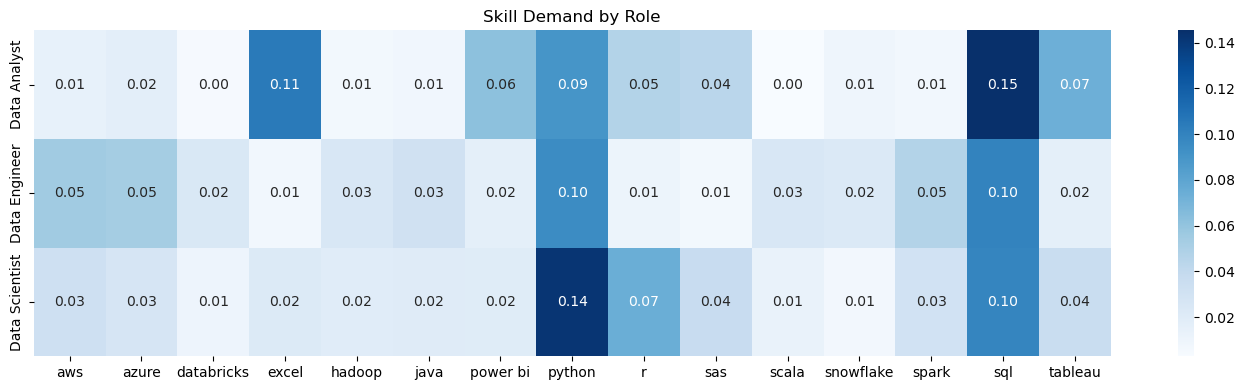

In [28]:
import seaborn as sns

plt.figure(figsize=(14, 4))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Skill Demand by Role")
plt.xlabel("")
plt.ylabel('')

plt.tight_layout()
plt.show()